In [1]:
#!pip install TCT

from TCT import node_normalizer
from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query
from TCT import TCT

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import pandas as pd
import numpy as np

In [26]:
# Translator_KP_info, APInames= translator_kpinfo.get_translator_kp_info()
# print(len(Translator_KP_info))
# # Step 2: Get metaKG and all predicates from Translator APIs through the SmartAPI system
# metaKG = translator_metakg.get_KP_metadata(APInames) 
# print(metaKG.shape)
# # Add metaKG from Plover API based KG resources
# APInames,metaKG = translator_metakg.add_plover_API(APInames, metaKG)
# print(metaKG.shape)
#     # Step 3: list metaKG information
# All_predicates = list(set(metaKG['Predicate']))
# All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
# API_withMetaKG = list(set(metaKG['API']))

# # generate a dictionary of API and its predicates
# API_predicates = {}
# for api in API_withMetaKG:
#     print(api)
#     API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

In [2]:
## Sanity check
import requests

url = 'https://amlkg.systemsbiology.org/AMLkg/meta_knowledge_graph'
response = requests.get(url)

print("Status code:", response.status_code)
print("Content-Type:", response.headers.get('Content-Type'))
print("Raw text (first 500 chars):")
print(response.text[:500])

Status code: 200
Content-Type: application/json
Raw text (first 500 chars):
{"edges":[{"attributes":[{"attribute_type_id":"biolink:publications","constraint_name":"publications","constraint_use":true},{"attribute_type_id":"subject_category","constraint_name":"subject category","constraint_use":true},{"attribute_type_id":"knowledge_source","constraint_name":"knowledge source","constraint_use":true},{"attribute_type_id":"biolink:knowledge_level","constraint_name":"knowledge level","constraint_use":true},{"attribute_type_id":"object_category","constraint_name":"object cate


In [3]:
Translator_KP_info, APInames= translator_kpinfo.get_translator_kp_info()
print(len(Translator_KP_info))
# Step 2: Get metaKG and all predicates from Translator APIs through the SmartAPI system
metaKG = translator_metakg.get_KP_metadata(APInames)

Skipping server without x-maturity: {'url': '/sipr'}
Skipping server without x-maturity: {'description': 'Local dev', 'url': 'http://127.0.0.1:5001'}
59


In [9]:
##############
## Note: this is the current correct way to call the API
###########
### Old, have issues
APInames_sele = {'AMLKG': 'https://amlkg.systemsbiology.org:9990/AMLkg/query'}
## New, no longer need to specify on port number
# APInames_sele = {'AMLKG': 'https://amlkg.systemsbiology.org/AMLkg/query'}
selected_KGs = ['AMLKG']

metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]

APInames_plover, metaKG_plover = translator_metakg.add_plover_API(APInames_sele, metaKG_sele)

In [10]:
print(APInames_plover)

{'AMLKG': 'https://amlkg.systemsbiology.org:9990/AMLkg/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query'}


In [4]:
##############
## Note: this is the current correct way to call the API
###########
### Old, have issues
# APInames_sele = {'AMLKG': 'https://amlkg.systemsbiology.org:9990/AMLkg/query'}
## New, no longer need to specify on port number
APInames_sele = {'AMLKG': 'https://amlkg.systemsbiology.org/AMLkg/query'}
selected_KGs = ['AMLKG']

metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]

APInames_plover, metaKG_plover = translator_metakg.add_plover_API(APInames_sele, metaKG_sele)

In [5]:
print(APInames_plover)

{'AMLKG': 'https://amlkg.systemsbiology.org/AMLkg/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query'}


In [6]:
print(metaKG_plover)

                                                     API  \
0      CATRAX BigGIM DrugResponse Performance Phase K...   
1      CATRAX BigGIM DrugResponse Performance Phase K...   
2      CATRAX BigGIM DrugResponse Performance Phase K...   
3      CATRAX BigGIM DrugResponse Performance Phase K...   
4      CATRAX BigGIM DrugResponse Performance Phase K...   
...                                                  ...   
11556                              RTX KG2 - TRAPI 1.5.0   
11557                              RTX KG2 - TRAPI 1.5.0   
11558                              RTX KG2 - TRAPI 1.5.0   
11559                              RTX KG2 - TRAPI 1.5.0   
11560                              RTX KG2 - TRAPI 1.5.0   

                                    Predicate                   Subject  \
0                        biolink:expressed_in              biolink:Gene   
1           biolink:physically_interacts_with              biolink:Gene   
2      biolink:gene_associated_with_condition         

In [6]:
# print(metaKG_plover[metaKG_plover['API'] == 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0'])

In [7]:
print(metaKG_plover[metaKG_plover['API'] == 'AMLKG'])

Empty DataFrame
Columns: [API, Predicate, Subject, Object, URL]
Index: []


In [8]:
print(APInames_plover)

{'AMLKG': 'https://amlkg.systemsbiology.org/AMLkg/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query'}


In [12]:
## add_plover_API() is hard-coded to existing KPs only!!
## need the general method to manually add the AMLKG kp

url = 'https://amlkg.systemsbiology.org/AMLkg/meta_knowledge_graph'
response = requests.get(url)
data = response.json()
for i in range(len(data["edges"])):
    APInames, metaKG = translator_metakg.add_new_API_for_query(APInames, metaKG, "AMLKG", "https://amlkg.systemsbiology.org/AMLkg/query", data["edges"][i]['predicate'], data["edges"][i]['subject'], data["edges"][i]['object'])

In [13]:
print(APInames)

{'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.transltr.io/ctkp/query/', 'ARAX Translator Reasoner - TRAPI 1.6.0': 'https://arax.transltr.io/api/arax/v1.4/query/', 'MolePro': 'https://molepro-trapi.transltr.io/molepro/trapi/v1.5/query/', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.transltr.io/query/', 'BioThings Explorer (BTE) TRAPI': 'https://bte.transltr.io/v1/query/', 'Gene-List Network Enrichment Analysis': 'https://translator.broadinstitute.org/gelinea-trapi/v1.5/query/', 'Autonomous Relay System (ARS) TRAPI': 'https://ars-prod.transltr.io/ars/api/submit/', 'Automat-reactome(Trapi v1.5.0)': 'https://automat.renci.org/reactome/query/', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.transltr.io/mokp/query/', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.transltr.io/dakp/query/', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.transltr.io/mbkp/query/', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.transltr.io/BigGIM_

In [14]:
print(metaKG[metaKG['API'] == 'AMLKG'])

         API                                          Predicate  \
11066  AMLKG                               biolink:expressed_in   
11067  AMLKG                                  biolink:regulates   
11068  AMLKG                                  biolink:regulates   
11069  AMLKG                                  biolink:regulates   
11070  AMLKG                                  biolink:regulates   
...      ...                                                ...   
11153  AMLKG             biolink:associated_with_sensitivity_to   
11154  AMLKG              biolink:associated_with_resistance_to   
11155  AMLKG  biolink:GeneToDiseaseOrPhenotypicFeatureAssoci...   
11156  AMLKG                                     biolink:treats   
11157  AMLKG                                biolink:subclass_of   

                             Subject                     Object  \
11066                   biolink:Gene               biolink:Cell   
11067                   biolink:Gene               biolink:Ge

In [12]:
# print(API_predicates)

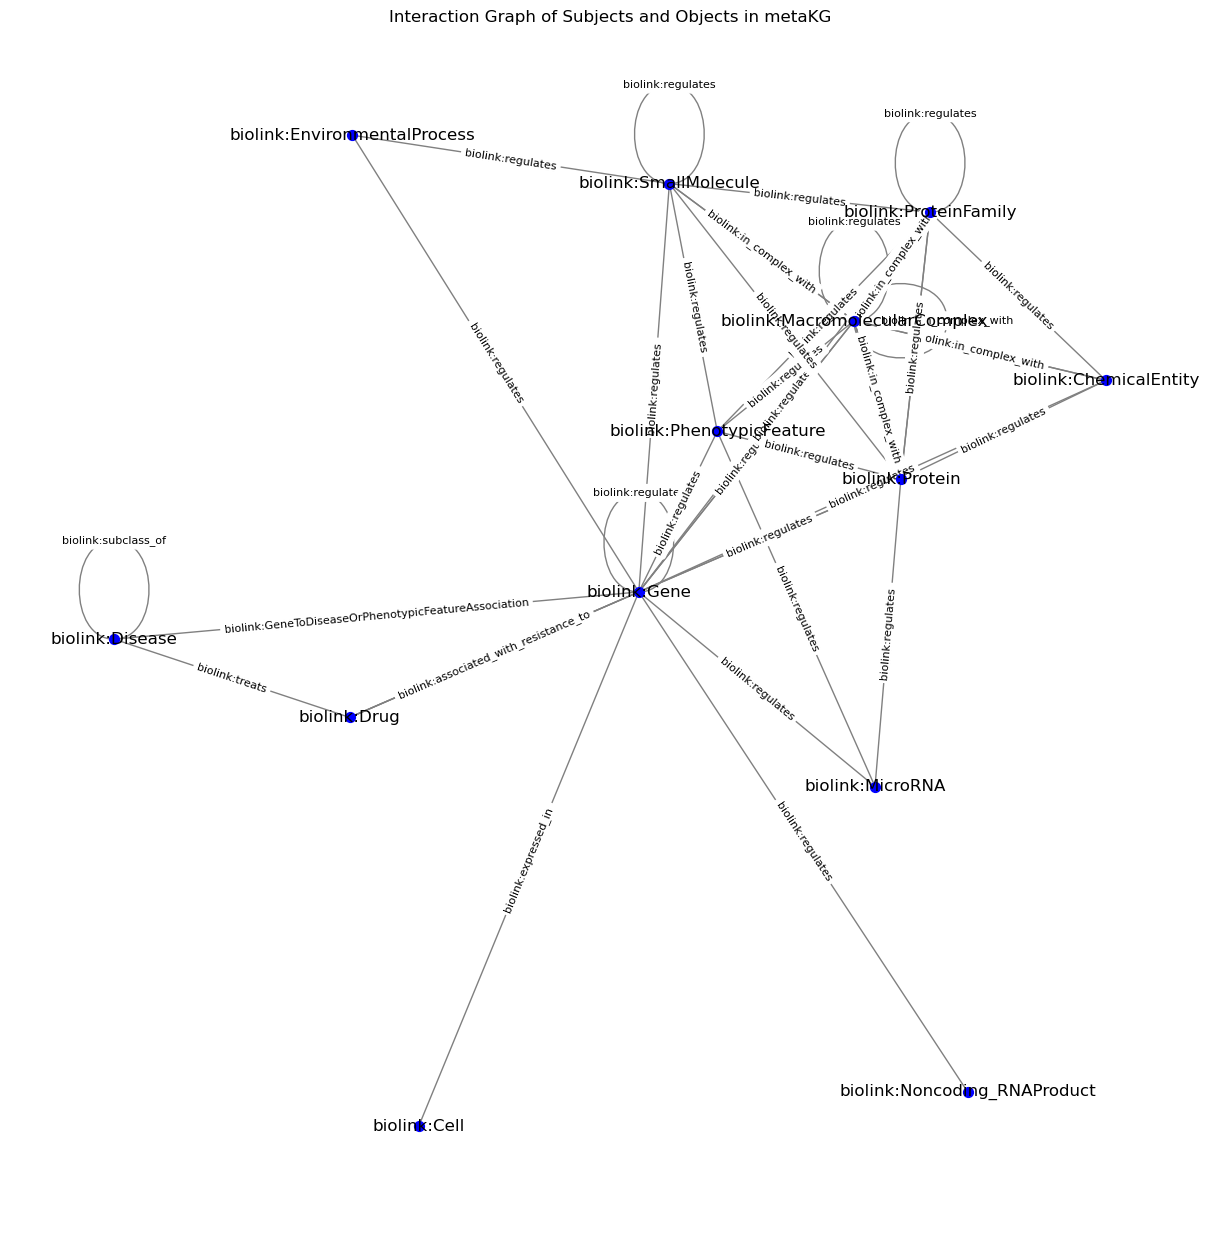

In [12]:
import networkx as nx
selected_KGs = ['AMLKG']

metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]

# build a multigraph to capture all edges (including duplicates) and their predicates
G = nx.MultiGraph()
for _, row in metaKG_sele.iterrows():
        G.add_edge(row['Subject'], row['Object'], predicate=row['Predicate'])

# layout and draw nodes + edges
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, iterations=20)
nx.draw(G, pos,
                with_labels=True,
                node_size=50,
                font_size=12,
                font_color='black',
                node_color='blue',
                edge_color='gray')

# draw edge labels
edge_labels = nx.get_edge_attributes(G, 'predicate')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
plt.title('Interaction Graph of Subjects and Objects in metaKG')
plt.show()

In [14]:
# metaKG_sele

In [15]:
# APInames

In [17]:
## This is the step missing, generate a dictionary of API and remember to add the new AMLKG one into this dictionary!!

All_predicates = list(set(metaKG['Predicate']))
API_withMetaKG = list(set(metaKG['API']))

# generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    print(api)
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

Automat-intact(Trapi v1.5.0)
Multiomics KP - TRAPI 1.5.0
MolePro
Automat-monarchinitiative(Trapi v1.5.0)
Automat-reactome(Trapi v1.5.0)
Automat-pharos(Trapi v1.5.0)
Connections Hypothesis Provider API
Automat-viral-proteome(Trapi v1.5.0)
Automat-hetionet(Trapi v1.5.0)
Automat-genome-alliance(Trapi v1.5.0)
Automat-hmdb(Trapi v1.5.0)
Automat-string-db(Trapi v1.5.0)
Gene-List Network Enrichment Analysis
Automat-gtopdb(Trapi v1.5.0)
Automat-gwas-catalog(Trapi v1.5.0)
Automat-binding-db(Trapi v1.5.0)
Automat-cam-kp(Trapi v1.5.0)
Automat-hgnc(Trapi v1.5.0)
Automat-ehr-may-treat-kp(Trapi v1.5.0)
Text Mined Cooccurrence API
CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0
AMLKG
Automat-ehr-clinical-connections-kp(Trapi v1.5.0)
Automat-human-goa(Trapi v1.5.0)
Automat-icees-kg(Trapi v1.5.0)
Clinical Trials KP - TRAPI 1.5.0
Genetics Data Provider for NCATS Biomedical Translator Reasoners
BioThings Explorer (BTE) TRAPI
Service Provider TRAPI
COHD TRAPI
Automat-gtex(Trapi v1.5.0)
RTX K

In [30]:
# print(API_predicates)

({'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'ARAX Translator Reasoner - TRAPI 1.6.0': 'https://arax.transltr.io/api/arax/v1.4/query/', 'MolePro': 'https://molepro-trapi.transltr.io/molepro/trapi/v1.5/query/', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query', 'BioThings Explorer (BTE) TRAPI': 'https://bte.transltr.io/v1/query/', 'Gene-List Network Enrichment Analysis': 'https://translator.broadinstitute.org/gelinea-trapi/v1.5/query/', 'Autonomous Relay System (ARS) TRAPI': 'https://ars-prod.transltr.io/ars/api/submit/', 'Automat-reactome(Trapi v1.5.0)': 'https://automat.renci.org/reactome/query/', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:99

In [ ]:
## use neiborhood_finder


input_node_id, result, result_parsed, result_ranked_by_primary_infores = TCT.Neiborhood_finder('AML',
                                                                                            node2_categories = ['biolink:SmallMolecule', 'biolink:Drug', 'biolink:ChemicalEntity'],
                                                                                            ## check all APIs
                                                                                            # APInames = APInames,
                                                                                            # metaKG = metaKG,
                                                                                            ## example of checking specific API
                                                                                            #APInames = {'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query'},
                                                                                            # APInames = {'AMLKG': 'https://amlkg.systemsbiology.org:9990/AMLkg/query'},
                                                                                            # metaKG = metaKG_sele,
                                                                                            APInames = APInames,
                                                                                            metaKG = metaKG,
                                                                                            API_predicates = API_predicates)    

UMLS:C5777113
'AMLKG' generated an exception: HTTPSConnectionPool(host='amlkg.systemsbiology.org', port=9990): Max retries exceeded with url: /AMLkg/query (Caused by SSLError(SSLError(1, '[SSL] record layer failure (_ssl.c:1006)')))
'Multiomics KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'CATRAX Pharmacogenomics KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'Microbiome KP - TRAPI 1.5.0' generated an exception: argument of type 'NoneType' is not iterable
'Automat-hetionet(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-ctd(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'Automat-viral-proteome(Trapi v1.5.0)' generated an exception: argument of type 'NoneType' is not iterable
'MolePro' generated an exception: argument of type 'NoneType' is not iterable
'Automat-string-db(Trapi v1.5.0)' generated an exception: argument of type 'No

In [ ]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores, result_parsed,
                                num_of_nodes = 50, input_query = input_node_id, 
                                fontsize = 5)

## Now only those KPs by Plover
* AML

In [27]:
# APInames_sele = {'AMLKG': 'https://amlkg.systemsbiology.org:9990/AMLkg/query'}
# selected_KGs = ['AMLKG']

# metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]

APInames_sele = {'AMLKG': 'https://amlkg.systemsbiology.org/AMLkg/query'}
selected_KGs = ['AMLKG']

# metaKG_sele = metaKG[metaKG['API'].isin(selected_KGs)]

APInames_plover, metaKG_plover = translator_metakg.add_plover_API(APInames_sele, metaKG_sele)

In [28]:
print(APInames_plover)
print(metaKG_plover)

{'AMLKG': 'https://amlkg.systemsbiology.org/AMLkg/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query'}
                         API                 Predicate  \
0                      AMLKG      biolink:expressed_in   
1                      AMLKG         biolink:regulates   
2                      AMLKG         biolink:regulates   
3                      AMLKG         biolink:regulates   
4            

In [29]:
## add_plover_API() is hard-coded to existing KPs only!!
## need the general method to manually add the AMLKG kp

url = 'https://amlkg.systemsbiology.org/AMLkg/meta_knowledge_graph'
response = requests.get(url)
data = response.json()
for i in range(len(data["edges"])):
    APInames_plover, metaKG_plover = translator_metakg.add_new_API_for_query(APInames_plover, metaKG_plover, "AMLKG", "https://amlkg.systemsbiology.org/AMLkg/query", data["edges"][i]['predicate'], data["edges"][i]['subject'], data["edges"][i]['object'])

In [44]:
print(APInames_plover)
print(metaKG_plover)

{'AMLKG': 'https://amlkg.systemsbiology.org/AMLkg/query', 'CATRAX BigGIM DrugResponse Performance Phase KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/BigGIM_DrugResponse_PerformancePhase/query', 'CATRAX Pharmacogenomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/PharmacogenomicsKG/query', 'Clinical Trials KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/ctkp/query', 'Drug Approvals KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/dakp/query', 'Multiomics KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/multiomics/query', 'Microbiome KP - TRAPI 1.5.0': 'https://multiomics.rtx.ai:9990/mbkp/query', 'RTX KG2 - TRAPI 1.5.0': 'https://kg2cploverdb.ci.transltr.io/kg2c/query'}
         API                                          Predicate  \
0      AMLKG                               biolink:expressed_in   
1      AMLKG                                  biolink:regulates   
2      AMLKG                                  biolink:regulates   
3      AMLKG                       

In [40]:
## use neiborhood_finder


input_node_id_amlkg, result_amlkg, result_parsed_amlkg, result_ranked_by_primary_infores_amlkg = TCT.Neiborhood_finder('AML',
                                                                                            node2_categories = ['biolink:SmallMolecule', 'biolink:Drug', 'biolink:ChemicalEntity', 'biolink:Gene', 'biolink:Cell'],
                                                                                            APInames = APInames_plover,
                                                                                            metaKG = metaKG_plover,
                                                                                            API_predicates = API_predicates)    

UMLS:C5777113
'AMLKG' generated an exception: tuple indices must be integers or slices, not str
'Multiomics KP - TRAPI 1.5.0' generated an exception: tuple indices must be integers or slices, not str
'CATRAX Pharmacogenomics KP - TRAPI 1.5.0' generated an exception: tuple indices must be integers or slices, not str
'RTX KG2 - TRAPI 1.5.0' generated an exception: tuple indices must be integers or slices, not str
'Microbiome KP - TRAPI 1.5.0' generated an exception: tuple indices must be integers or slices, not str


In [42]:
print(result_ranked_by_primary_infores_amlkg)

Empty DataFrame
Columns: [output_node, Name, Num_of_primary_infores, type_of_nodes, unique_predicates]
Index: []


ValueError: zero-size array to reduction operation fmin which has no identity

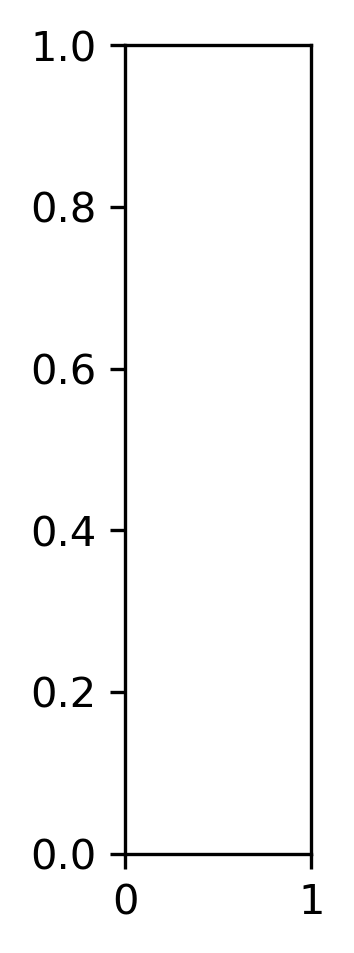

In [43]:
# Step 8: Visualize the results
TCT.visulization_one_hop_ranking(result_ranked_by_primary_infores_amlkg, result_parsed_amlkg,
                                num_of_nodes = 50, input_query = input_node_id_amlkg, 
                                fontsize = 5)